In [1]:
%run ./notebook_setup.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.config import load_config

/home/inventor/Churn_Prediction_Project


In [2]:
config = load_config()

In [3]:
config

{'paths': {'train_raw_data': '/home/inventor/Churn_Prediction_Project/data/raw/train.csv',
  'test_raw_data': '/home/inventor/Churn_Prediction_Project/data/raw/test.csv',
  'description_of_data': '/home/inventor/Churn_Prediction_Project/data/raw/data_descriptions.csv',
  'preprocessed_data_dir': '/home/inventor/Churn_Prediction_Project/data/preprocessed',
  'model_dir': '/home/inventor/Churn_Prediction_Project/models',
  'output_dir': '/home/inventor/Churn_Prediction_Project/output'},
 'data': {'test_size': 0.2, 'random_state': 42}}

In [4]:
raw_train_data = config["paths"]["train_raw_data"]
raw_test_data = config["paths"]["test_raw_data"]

In [29]:
raw_train_df = pd.read_csv(raw_train_data)
raw_test_df = pd.read_csv(raw_test_data)

In [6]:
raw_train_df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [7]:
raw_test_df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID
0,38,17.869374,679.036195,Premium,Mailed check,No,TV Shows,No,TV,29.126308,122.274031,42,Comedy,3.522724,2,Male,23,No,No,O1W6BHP6RM
1,77,9.912854,763.289768,Basic,Electronic check,Yes,TV Shows,No,TV,36.873729,57.093319,43,Action,2.021545,2,Female,22,Yes,No,LFR4X92X8H
2,5,15.019011,75.095057,Standard,Bank transfer,No,TV Shows,Yes,Computer,7.601729,140.414001,14,Sci-Fi,4.806126,2,Female,22,No,Yes,QM5GBIYODA
3,88,15.357406,1351.451692,Standard,Electronic check,No,Both,Yes,Tablet,35.586430,177.002419,14,Comedy,4.943900,0,Female,23,Yes,Yes,D9RXTK2K9F
4,91,12.406033,1128.949004,Standard,Credit card,Yes,TV Shows,Yes,Tablet,23.503651,70.308376,6,Drama,2.846880,6,Female,0,No,No,ENTCCHR1LR


In [8]:
raw_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  str    
 4   PaymentMethod             243787 non-null  str    
 5   PaperlessBilling          243787 non-null  str    
 6   ContentType               243787 non-null  str    
 7   MultiDeviceAccess         243787 non-null  str    
 8   DeviceRegistered          243787 non-null  str    
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  str    
 13  UserRating                243787 non-null  float64
 14 

In [9]:
raw_test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104480 entries, 0 to 104479
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                104480 non-null  int64  
 1   MonthlyCharges            104480 non-null  float64
 2   TotalCharges              104480 non-null  float64
 3   SubscriptionType          104480 non-null  str    
 4   PaymentMethod             104480 non-null  str    
 5   PaperlessBilling          104480 non-null  str    
 6   ContentType               104480 non-null  str    
 7   MultiDeviceAccess         104480 non-null  str    
 8   DeviceRegistered          104480 non-null  str    
 9   ViewingHoursPerWeek       104480 non-null  float64
 10  AverageViewingDuration    104480 non-null  float64
 11  ContentDownloadsPerMonth  104480 non-null  int64  
 12  GenrePreference           104480 non-null  str    
 13  UserRating                104480 non-null  float64
 14 

In [10]:
raw_train_df.isnull().sum()

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
Churn                       0
dtype: int64

In [11]:
raw_test_df.isnull().sum()

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
dtype: int64

In [12]:
raw_train_df.duplicated().sum(), raw_test_df.duplicated().sum()

(np.int64(0), np.int64(0))

## Preprocessing Phase
- Handle Missing Values -> In our case there is no missing value.
- Remove duplicate values -> In our data there is no duplicated values.
- Remove Useless Features -> In our data there is two features __UserRating__ and __CustomerID__.
- Feature Engineering - if possible.
- Remove Outliers from __totalcharge__.
- Embedding the data into numeric representation.
- Train and Test split of the data - In our case there is no need because we have dataset indvidualy for train and test split.
- validation dataset.
- Simple Model test to ensure of preprocess phase.

In [30]:
raw_train_df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='str')

In [31]:
# Remove Useles
new_raw_train_df = raw_train_df.drop(columns=["UserRating", "CustomerID"])
new_raw_test_df = raw_test_df.drop(columns=["UserRating", "CustomerID"])

In [32]:
new_raw_train_df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,4,Female,0,No,No,0


In [33]:
#  Remove outliers 
from feature_engine.outliers import ArbitraryOutlierCapper

In [34]:
totalcharge_q1 = new_raw_train_df["TotalCharges"].quantile(0.25)
totalcharge_q3 = new_raw_train_df["TotalCharges"].quantile(0.75)

IQR = totalcharge_q3 - totalcharge_q1

lower_bound_totalcharge = totalcharge_q1 - 1.5 * IQR
upper_bound_totalcharge = totalcharge_q3 + 1.5 * IQR

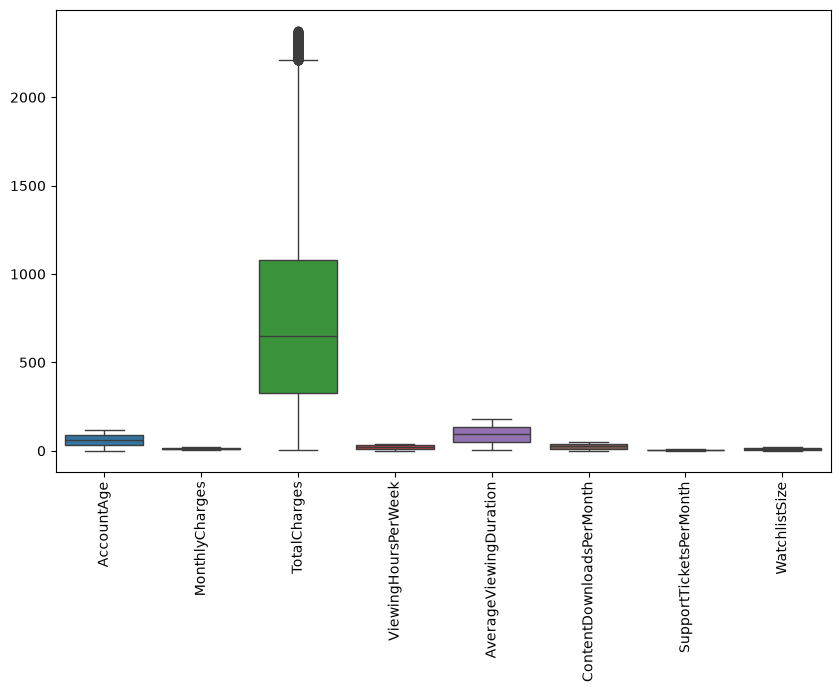

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(new_raw_train_df)
plt.xticks(rotation=90)
plt.show()

In [35]:
capper = ArbitraryOutlierCapper(
    min_capping_dict={"TotalCharges": lower_bound_totalcharge},
    max_capping_dict={"TotalCharges": upper_bound_totalcharge}
)

In [36]:
raw_train_df_transformed = capper.fit_transform(new_raw_train_df)

In [37]:
raw_train_df_transformed.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,4,Female,0,No,No,0


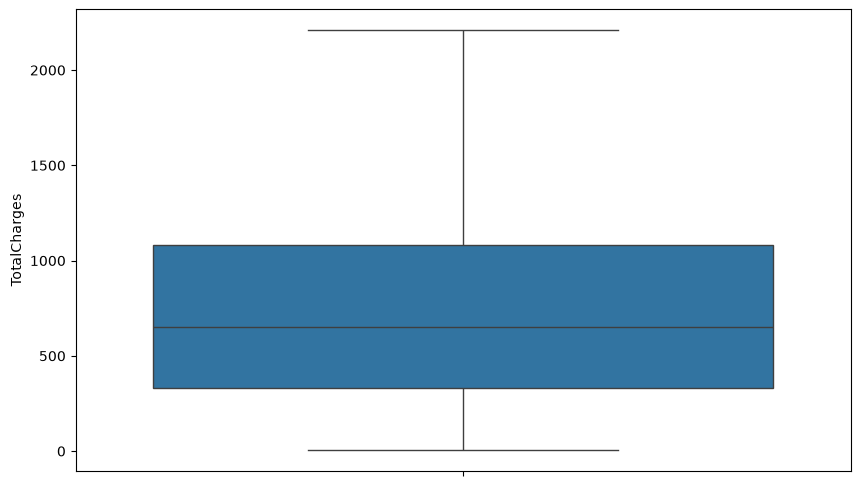

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(raw_train_df_transformed["TotalCharges"])
plt.show()

In [38]:
raw_train_df_transformed["Churn"].value_counts()

Churn
0    199605
1     44182
Name: count, dtype: int64

In [40]:
raw_train_df_transformed.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'SupportTicketsPerMonth',
       'Gender', 'WatchlistSize', 'ParentalControl', 'SubtitlesEnabled',
       'Churn'],
      dtype='str')

In [66]:
X_train_full = raw_train_df_transformed.drop(columns='Churn')
y_train_full = raw_train_df_transformed["Churn"]

In [62]:
X_test = new_raw_test_df

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full,
    test_size=config["data"]["test_size"],
    random_state=config["data"]["random_state"]
)

In [59]:
transformed_cat_features = [feature for feature in X_train.columns if X_train[feature].dtype not in [int, float]]
transformed_numeric_features = [feature for feature in X_train.columns if X_train[feature].dtype in [int, float]]

In [60]:
transformed_cat_features

['SubscriptionType',
 'PaymentMethod',
 'PaperlessBilling',
 'ContentType',
 'MultiDeviceAccess',
 'DeviceRegistered',
 'GenrePreference',
 'Gender',
 'ParentalControl',
 'SubtitlesEnabled']

In [61]:
transformed_numeric_features

['AccountAge',
 'MonthlyCharges',
 'TotalCharges',
 'ViewingHoursPerWeek',
 'AverageViewingDuration',
 'ContentDownloadsPerMonth',
 'SupportTicketsPerMonth',
 'WatchlistSize']

In [72]:
# Embedding into numeric representation
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'), transformed_cat_features),
        ('scaler', StandardScaler(), transformed_numeric_features)
    ], remainder='drop'
)


In [74]:
X_train_transformed = preprocess.fit_transform(X_train)
X_val_transformed = preprocess.transform(X_val)
transformed_test_df = preprocess.transform(X_test)

In [75]:
X_train_transformed

array([[ 1.        ,  0.        ,  0.        , ...,  1.14307837,
         1.21832713,  0.4139387 ],
       [ 0.        ,  1.        ,  0.        , ...,  0.79637493,
        -1.56449431,  1.52575443],
       [ 0.        ,  0.        ,  1.        , ..., -0.7291202 ,
        -0.17308359, -0.00299219],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -1.69988982,
        -1.21664163, -0.41992309],
       [ 0.        ,  0.        ,  1.        , ..., -0.59043882,
         0.52262177, -0.41992309],
       [ 0.        ,  0.        ,  1.        , ..., -0.86780157,
         1.56617981, -0.00299219]], shape=(195029, 32))

## Overview of Preprocess Phase
- First remove useless feature __UserRating__ and __CustomerID__.
- Then Remove outlier of __TotalCharges__ using `ArbitraryOutlierCapper`.
- Then do OneHotEncoder on Category feature.
- And `StandardScaler` on numeric features.